In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import os

from statsmodels.miscmodels.ordinal_model import OrderedModel

%load_ext autoreload
%autoreload 2

import utils.columns as cols
import utils.transform as transform
import utils.univariate as univar
import utils.bivariate as bivar
import utils.ordinal_regression as ordinal
import utils.experiment as experiment


# Read Preprocessed Mental, Social, and Green Space Datasets

In [2]:
# Define the base directory
BASE_PATH = '../final_data/processed'

# Load datasets using a dictionary comprehension
files = {
    'mental': f'{BASE_PATH}/medical/basis/mental_health_dataset_b.xlsx',
    'social': f'{BASE_PATH}/medical/basis/social_factors_dataset_b.xlsx',
    'green': f'{BASE_PATH}/environmental/basis/green_space_dataset_b.xlsx'
}

datasets = {name: pd.read_excel(path, index_col=0) for name, path in files.items()}

# Combine all datasets at once along the index (columns/horizontal alignment)
data_complete = pd.concat(datasets.values(), axis=1, join='outer')


In [3]:
data_complete = transform.rename_columns(data_complete)

# Age grouping

In [4]:
data_complete['Age_group'] = transform.categorize(
    data_complete, 'Age', bins=[0,40,53,65,np.inf], right=False, labels=["[18, 40)","[40, 53)","[53, 65)","[65, 81)"]
)

# Outcome Direction Map

In [5]:
outcome_direction_map = {
    "CES-D Ordinal":  {"direction": "higher_is_worse", "label": "more severe depressive symptoms"},
    "GAD-7 Ordinal":  {"direction": "higher_is_worse", "label": "more severe anxiety symptoms"},
    "SWLS Ordinal":   {"direction": "higher_is_better", "label": "better life satisfaction"},
}

# Ordinal Model: Mental Health Scores across Green Exposures

## NDVI – continuous

In [8]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.ndvi

results_df, model_store = experiment.run_ordinal_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Ordinal × NDVI (100m Buffer)
  [2/12] CES-D Ordinal × NDVI (200m Buffer)
  [3/12] CES-D Ordinal × NDVI (500m Buffer)
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)
  [5/12] GAD-7 Ordinal × NDVI (100m Buffer)
  [6/12] GAD-7 Ordinal × NDVI (200m Buffer)
  [7/12] GAD-7 Ordinal × NDVI (500m Buffer)
  [8/12] GAD-7 Ordinal × NDVI (1000m Buffer)
  [9/12] SWLS Ordinal × NDVI (100m Buffer)
  [10/12] SWLS Ordinal × NDVI (200m Buffer)
  [11/12] SWLS Ordinal × NDVI (500m Buffer)
  [12/12] SWLS Ordinal × NDVI (1000m Buffer)

  Grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,scale_predictor,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
0,CES-D Ordinal,NDVI (100m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.208,0.812,0.739,0.893,"0.812 (0.739, 0.893)",1.656433e-05,<0.001,18.8,18.8% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
1,CES-D Ordinal,NDVI (200m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.250,0.779,0.704,0.862,"0.779 (0.704, 0.862)",1.273079e-06,<0.001,22.1,22.1% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.216,0.806,0.726,0.895,"0.806 (0.726, 0.895)",5.456719e-05,<0.001,19.4,19.4% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
3,CES-D Ordinal,NDVI (1000m Buffer),continuous,9117,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.201,0.818,0.732,0.914,"0.818 (0.732, 0.914)",3.915652e-04,<0.001,18.2,18.2% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
4,GAD-7 Ordinal,NDVI (100m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (100m Buffer),-0.053,0.948,0.900,0.999,"0.948 (0.900, 0.999)",4.440700e-02,0.044,5.2,5.2% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
5,GAD-7 Ordinal,NDVI (200m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (200m Buffer),-0.065,0.937,0.887,0.990,"0.937 (0.887, 0.990)",2.019597e-02,0.020,6.3,6.3% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (500m Buffer),-0.100,0.905,0.855,0.958,"0.905 (0.855, 0.958)",5.619107e-04,<0.001,9.5,9.5% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
7,GAD-7 Ordinal,NDVI (1000m Buffer),continuous,9278,higher_is_worse,0.1,None,NDVI (1000m Buffer),-0.096,0.909,0.856,0.965,"0.909 (0.856, 0.965)",1.930284e-03,0.002,9.1,9.1% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
8,SWLS Ordinal,NDVI (100m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (100m Buffer),0.153,1.166,1.114,1.219,"1.166 (1.114, 1.219)",2.547770e-11,<0.001,16.6,16.6% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
9,SWLS Ordinal,NDVI (200m Buffer),continuous,9297,higher_is_better,0.1,None,NDVI (200m Buffer),0.186,1.205,1.149,1.264,"1.205 (1.149, 1.264)",1.820416e-14,<0.001,20.5,20.5% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)",HC3


## Save Linear Regression results to `ordinal_results` in `pkl` and `csv`

In [9]:
##out_path = f"outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results"
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results.csv


## Land-use-based Green Space – Quartiles

In [12]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.greenspace_quartiles

results_df, model_store = experiment.run_ordinal_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Age", "Sex", "Socioeconomic Status (Tiers)"],
)

display(results_df)

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)
  [5/12] GAD-7 Ordinal × Green Space Quartile (100m Buffer)
  [6/12] GAD-7 Ordinal × Green Space Quartile (200m Buffer)
  [7/12] GAD-7 Ordinal × Green Space Quartile (500m Buffer)
  [8/12] GAD-7 Ordinal × Green Space Quartile (1000m Buffer)
  [9/12] SWLS Ordinal × Green Space Quartile (100m Buffer)
  [10/12] SWLS Ordinal × Green Space Quartile (200m Buffer)
  [11/12] SWLS Ordinal × Green Space Quartile (500m Buffer)
  [12/12] SWLS Ordinal × Green Space Quartile (1000m Buffer)

  Grid complete: 12/12 models fitted.


,outcome,predictor,predictor_type,n,outcome_direction,reference_category,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
0,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.060,0.941,0.752,1.179,"0.941 (0.752, 1.179)",5.982897e-01,0.598,5.9,5.9% lower odds of more severe depressive symp...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
1,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.100,0.905,0.719,1.138,"0.905 (0.719, 1.138)",3.923583e-01,0.392,9.5,9.5% lower odds of more severe depressive symp...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
2,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.256,0.774,0.609,0.984,"0.774 (0.609, 0.984)",3.627589e-02,0.036,22.6,22.6% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
3,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.261,0.770,0.616,0.963,"0.770 (0.616, 0.963)",2.170714e-02,0.022,23.0,23.0% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
4,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.365,0.694,0.551,0.875,"0.694 (0.551, 0.875)",2.035092e-03,0.002,30.6,30.6% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
5,CES-D Ordinal,Green Space Quartile (200m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.290,0.748,0.594,0.942,"0.748 (0.594, 0.942)",1.355084e-02,0.014,25.2,25.2% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
6,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,-0.129,0.879,0.701,1.103,"0.879 (0.701, 1.103)",2.666094e-01,0.267,12.1,12.1% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
7,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q3,-0.161,0.851,0.678,1.069,"0.851 (0.678, 1.069)",1.657410e-01,0.166,14.9,14.9% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q4,-0.182,0.833,0.661,1.051,"0.833 (0.661, 1.051)",1.232760e-01,0.123,16.7,16.7% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3
9,CES-D Ordinal,Green Space Quartile (1000m Buffer),categorical,9079,higher_is_worse,1.0,Q1,Q2,0.020,1.020,0.816,1.275,"1.020 (0.816, 1.275)",8.629758e-01,0.863,2.0,2.0% higher odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)",HC3


## Save Ordered Regression results to `ordinal_results` in `pkl` and `csv`

In [13]:
##out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results" ## ndvi | quartiles
##experiment.save_results(results_df, model_store, path=out_path)

  Saved pickle : outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results.csv


# Load Ordinal Model results from `ordinal_results.pkl`

In [ ]:
##out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results" ## ndvi | quartiles
##results_df, model_store = experiment.load_results(out_path)

# Analysis – Mental Ordinal Scores vs Green Exposures

## NDVI – Ordinal model – unadjusted

In [14]:
out_path = f"outputs/ordinal/mental_ordinal/ndvi/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

#results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]
results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:20:37.009160


,outcome,predictor,predictor_type,n,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9142,0.1,-0.251,"0.778 (0.704, 0.859)",<0.001,22.2,22.2% lower odds of more severe depressive sym...,unadjusted
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9304,0.1,-0.108,"0.897 (0.849, 0.949)",<0.001,10.3,10.3% lower odds of more severe anxiety sympto...,unadjusted
10,SWLS Ordinal,NDVI (500m Buffer),continuous,9323,0.1,0.208,"1.232 (1.174, 1.292)",<0.001,23.2,23.2% higher odds of better life satisfaction ...,unadjusted


## NDVI – Ordinal model – adjusted: Sex, Age, SES

In [15]:
out_path = f"outputs/ordinal/mental_ordinal/ndvi/adjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "predictor_type", "n", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:21:04.344574


,outcome,predictor,predictor_type,n,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
2,CES-D Ordinal,NDVI (500m Buffer),continuous,9117,0.1,-0.216,"0.806 (0.726, 0.895)",<0.001,19.4,19.4% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
6,GAD-7 Ordinal,NDVI (500m Buffer),continuous,9278,0.1,-0.100,"0.905 (0.855, 0.958)",<0.001,9.5,9.5% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
10,SWLS Ordinal,NDVI (500m Buffer),continuous,9297,0.1,0.180,"1.198 (1.141, 1.257)",<0.001,19.8,19.8% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"


## Land-use-based Quartiles – Ordinal model – unadjusted

In [16]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:21:38.081728


,outcome,predictor,predictor_type,n,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9104,Q1,Q4,-0.309,"0.734 (0.585, 0.922)",0.008,26.6,26.6% lower odds of more severe depressive sym...,unadjusted
20,GAD-7 Ordinal,Green Space Quartile (500m Buffer),categorical,9264,Q1,Q4,-0.146,"0.864 (0.764, 0.978)",0.020,13.6,13.6% lower odds of more severe anxiety sympto...,unadjusted
32,SWLS Ordinal,Green Space Quartile (500m Buffer),categorical,9283,Q1,Q4,0.497,"1.645 (1.480, 1.827)",<0.001,64.5,64.5% higher odds of better life satisfaction ...,unadjusted


## Land-use-based Quartiles – Ordinal model – adjusted: Sex, Age, SES

In [17]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/adjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "predictor_type", "n", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

results_df.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:22:06.317688


,outcome,predictor,predictor_type,n,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,Green Space Quartile (500m Buffer),categorical,9079,Q1,Q4,-0.182,"0.833 (0.661, 1.051)",0.123,16.7,16.7% lower odds of more severe depressive sym...,"Age, Sex, Socioeconomic Status (Tiers)"
20,GAD-7 Ordinal,Green Space Quartile (500m Buffer),categorical,9238,Q1,Q4,-0.099,"0.906 (0.800, 1.027)",0.122,9.4,9.4% lower odds of more severe anxiety symptom...,"Age, Sex, Socioeconomic Status (Tiers)"
32,SWLS Ordinal,Green Space Quartile (500m Buffer),categorical,9257,Q1,Q4,0.423,"1.526 (1.372, 1.698)",<0.001,52.6,52.6% higher odds of better life satisfaction ...,"Age, Sex, Socioeconomic Status (Tiers)"


# Plot FOREST – Mental Ordinal Score vs. Green Exposure Quartiles

  Loaded results saved at: 2026-09-14T17:21:38.081728


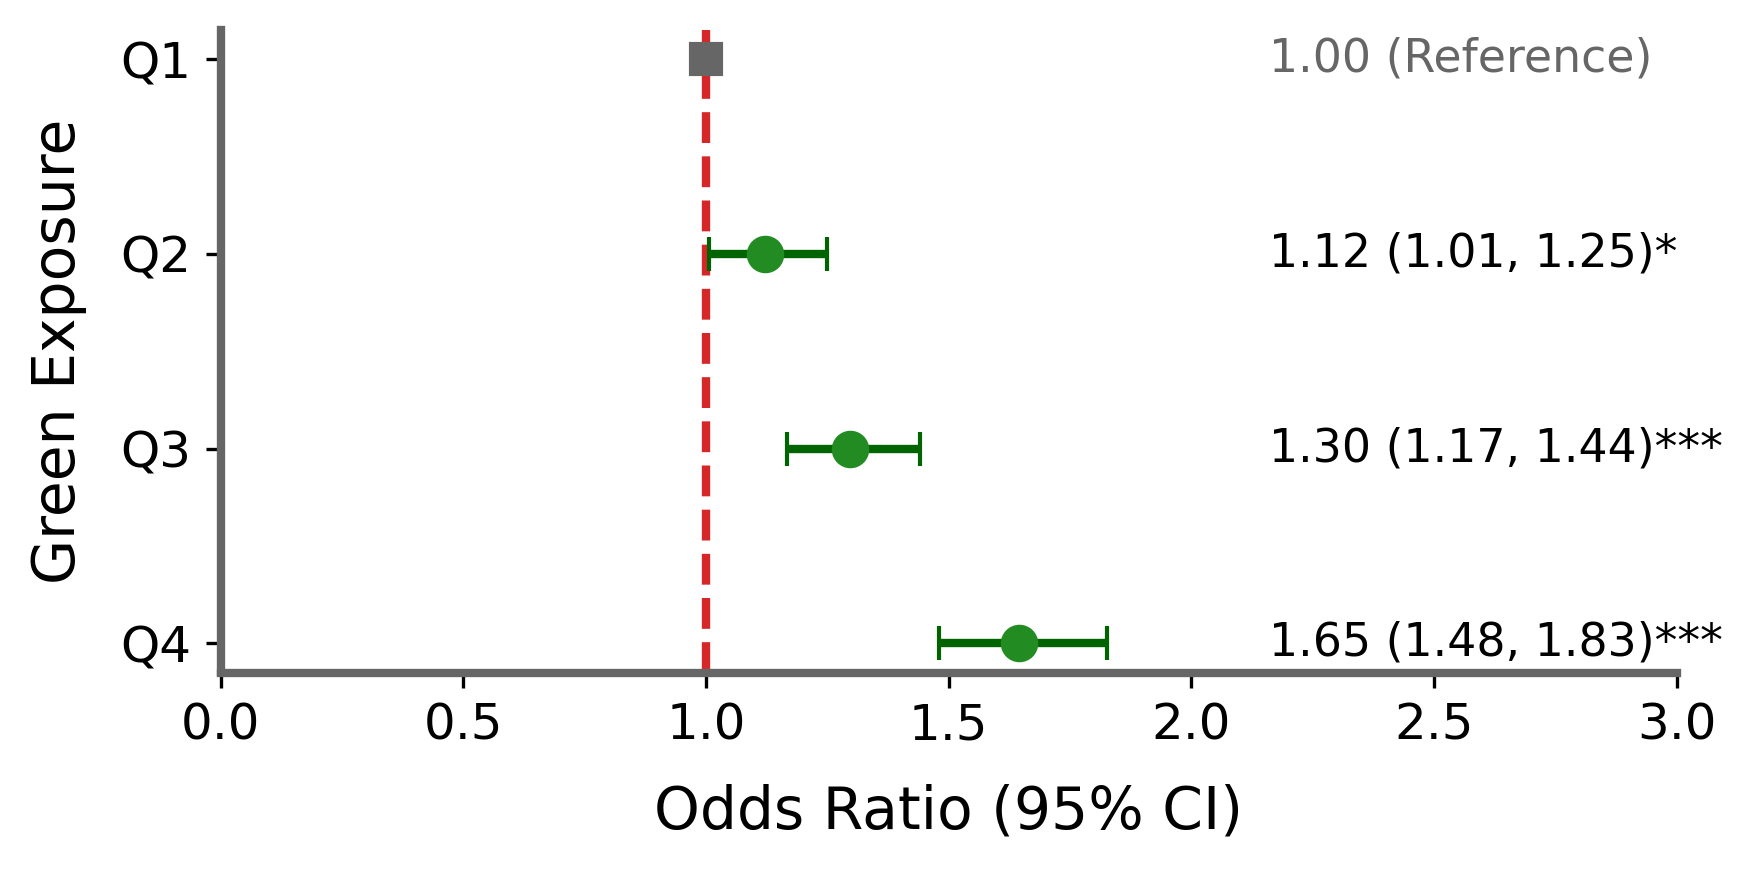

In [18]:
out_path = f"outputs/ordinal/mental_ordinal/quartiles/unadjusted/ordinal_results"
results_df, model_store = experiment.load_results(out_path)

outcome = cols.mental_ordinal[2]
predictor = cols.greenspace_quartiles[2]
df_plot = results_df.query(f"outcome == @outcome and predictor == @predictor")
ordinal.plot_forest(df_plot)#, save_path='out.png')

# Plot PROFILE – Mental Ordinal Score vs. Green Exposure Quartiles

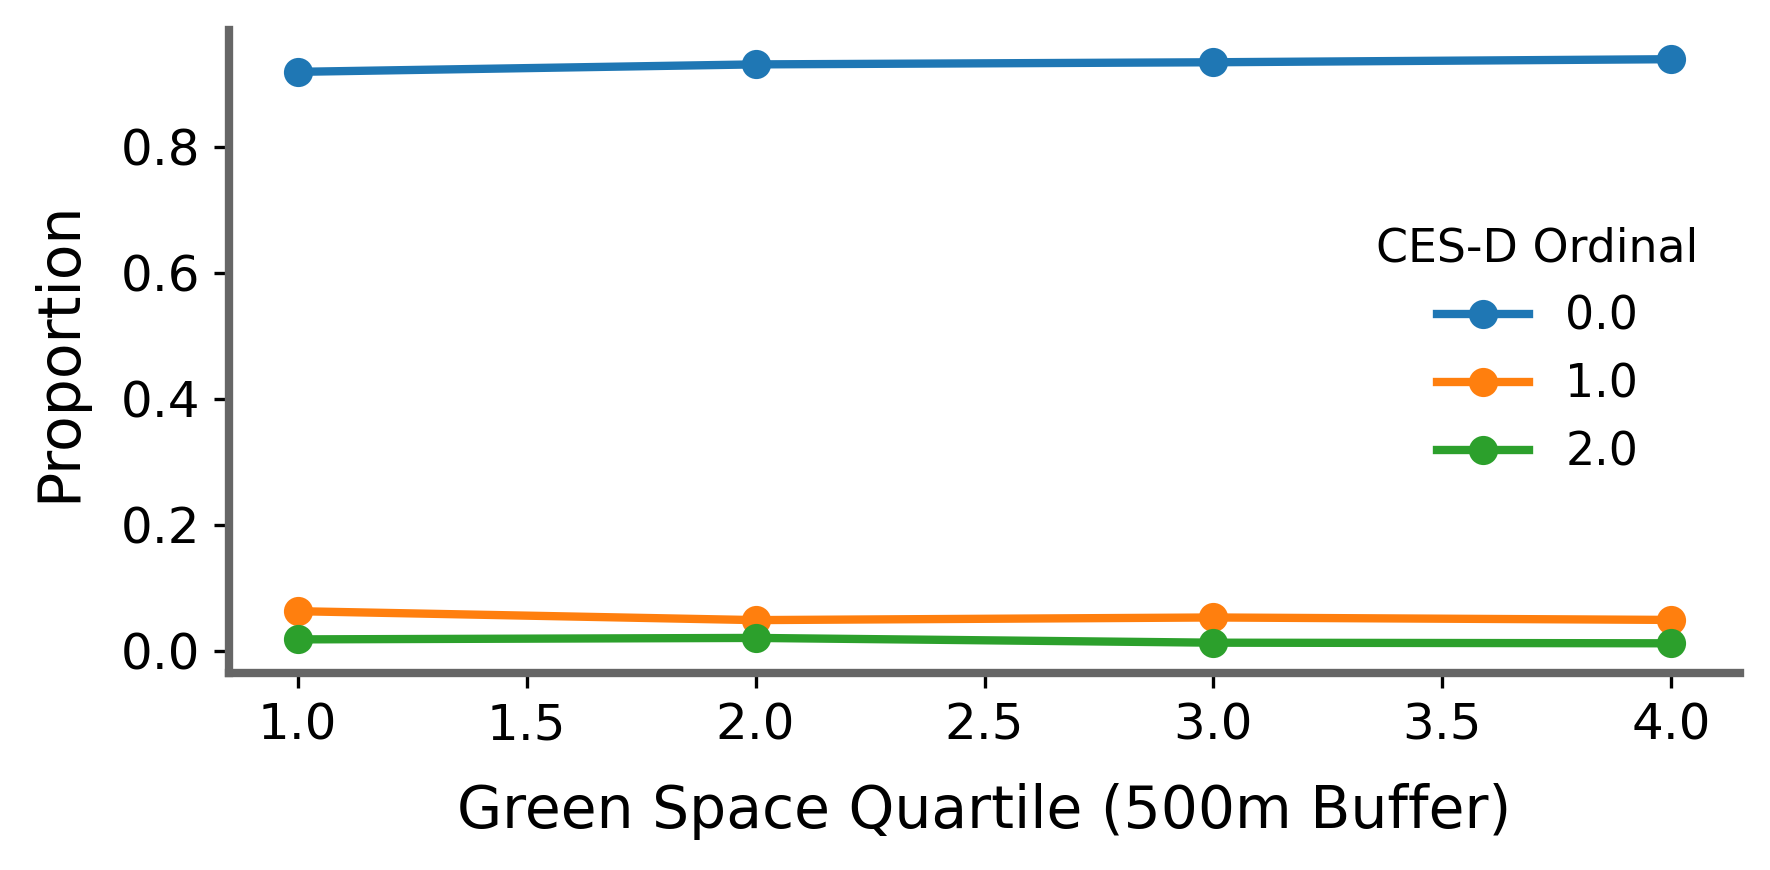

In [19]:
outcome = 'CES-D Ordinal'
predictor = 'Green Space Quartile (500m Buffer)'
profile_table, fig, ax = ordinal.plot_profile(data, outcome, predictor, predictor_type='categorical')

# Ordinal Model – Single Mental Health Variable

In [20]:
data = data_complete.copy()

outcome = cols.mental_ordinal[2]
predictor = cols.greenspace_quartiles[1]
#predictor = cols.ndvi[2]

result, metadata = ordinal.fit_model(data, outcome, predictor, predictor_type="categorical")#, covariates=['Sex', 'Age'])

In [21]:
results_df = ordinal.extract_results(
    result,
    metadata
)
print(f"outcome: {metadata['outcome']}, \npredictor: {metadata['predictor']}")
display(results_df)

outcome: SWLS Ordinal, 
predictor: Green Space Quartile (200m Buffer)


,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
0,Q1,Q2,0.133,1.142,1.025,1.272,"1.142 (1.025, 1.272)",1.579752e-02,0.016,14.2,14.2% higher odds of better outcome (SWLS Ordi...,unadjusted,HC3
1,Q1,Q3,0.260,1.297,1.166,1.442,"1.297 (1.166, 1.442)",1.772337e-06,<0.001,29.7,29.7% higher odds of better outcome (SWLS Ordi...,unadjusted,HC3
2,Q1,Q4,0.499,1.648,1.481,1.834,"1.648 (1.481, 1.834)",5.733171e-20,<0.001,64.8,64.8% higher odds of better outcome (SWLS Ordi...,unadjusted,HC3


# Stratified Ordinal Model – Experiments

## SES-stratified: Mental Ordinal Scores across NDVI

In [32]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.ndvi

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "ordinal",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Ordinal × NDVI (100m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Ordinal × NDVI (200m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Ordinal × NDVI (500m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (T

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,scale_predictor,reference_level,level,...,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
0,CES-D Ordinal,NDVI (100m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (100m Buffer),...,0.844,0.723,0.985,"0.844 (0.723, 0.985)",3.120942e-02,0.031,15.6,15.6% lower odds of more severe depressive sym...,"Sex, Age",HC3
1,CES-D Ordinal,NDVI (100m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (100m Buffer),...,0.823,0.718,0.944,"0.823 (0.718, 0.944)",5.236599e-03,0.005,17.7,17.7% lower odds of more severe depressive sym...,"Sex, Age",HC3
2,CES-D Ordinal,NDVI (100m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (100m Buffer),...,0.728,0.571,0.929,"0.728 (0.571, 0.929)",1.074894e-02,0.011,27.2,27.2% lower odds of more severe depressive sym...,"Sex, Age",HC3
3,CES-D Ordinal,NDVI (200m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (200m Buffer),...,0.838,0.711,0.987,"0.838 (0.711, 0.987)",3.479666e-02,0.035,16.2,16.2% lower odds of more severe depressive sym...,"Sex, Age",HC3
4,CES-D Ordinal,NDVI (200m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (200m Buffer),...,0.771,0.665,0.893,"0.771 (0.665, 0.893)",5.091281e-04,<0.001,22.9,22.9% lower odds of more severe depressive sym...,"Sex, Age",HC3
5,CES-D Ordinal,NDVI (200m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (200m Buffer),...,0.707,0.549,0.912,"0.707 (0.549, 0.912)",7.490030e-03,0.007,29.3,29.3% lower odds of more severe depressive sym...,"Sex, Age",HC3
6,CES-D Ordinal,NDVI (500m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (500m Buffer),...,0.817,0.694,0.961,"0.817 (0.694, 0.961)",1.468321e-02,0.015,18.3,18.3% lower odds of more severe depressive sym...,"Sex, Age",HC3
7,CES-D Ordinal,NDVI (500m Buffer),continuous,5475,Socioeconomic Status (Tiers),2.0,higher_is_worse,0.1,None,NDVI (500m Buffer),...,0.802,0.686,0.937,"0.802 (0.686, 0.937)",5.466526e-03,0.005,19.8,19.8% lower odds of more severe depressive sym...,"Sex, Age",HC3
8,CES-D Ordinal,NDVI (500m Buffer),continuous,1844,Socioeconomic Status (Tiers),3.0,higher_is_worse,0.1,None,NDVI (500m Buffer),...,0.815,0.628,1.057,"0.815 (0.628, 1.057)",1.234777e-01,0.123,18.5,18.5% lower odds of more severe depressive sym...,"Sex, Age",HC3
9,CES-D Ordinal,NDVI (1000m Buffer),continuous,1798,Socioeconomic Status (Tiers),1.0,higher_is_worse,0.1,None,NDVI (1000m Buffer),...,0.819,0.682,0.983,"0.819 (0.682, 0.983)",3.186728e-02,0.032,18.1,18.1% lower odds of more severe depressive sym...,"Sex, Age",HC3


## Save Stratified Regression results to `ordinal_results` in `pkl` and `csv`

In [33]:
##out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results.csv


## SES-stratified: Mental Ordinal Scores across Green Space Quartiles

In [44]:
data = data_complete.copy()

outcomes = cols.mental_ordinal
predictors = cols.greenspace_quartiles

strata_results, strata_summary = experiment.run_stratified_grid(
    data                  = data,
    outcomes              = outcomes,
    predictors            = predictors,
    stratify_by           = "Socioeconomic Status (Tiers)",
#    strata                = [1, 2, 3],
    model_type            = "ordinal",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"]
)

display(strata_results)

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic Status (Tiers) = 1.0  (n = 1995)
  Stratum Socioeconomic Status (Tiers) = 2.0  (n = 5994)
  Stratum Socioeconomic Status (Tiers) = 3.0  (n = 1974)
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)  [stratified by Socioeconomic Status (Tiers), ordinal]
  Stratum Socioeconomic St

,outcome,predictor,predictor_type,n,stratum_var,stratum,outcome_direction,reference_category,reference_level,level,...,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
0,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q2,...,1.019,0.703,1.477,"1.019 (0.703, 1.477)",9.223676e-01,0.922,1.9,1.9% higher odds of more severe depressive sym...,"Sex, Age",HC3
1,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q3,...,0.866,0.578,1.297,"0.866 (0.578, 1.297)",4.849658e-01,0.485,13.4,13.4% lower odds of more severe depressive sym...,"Sex, Age",HC3
2,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,1788,Socioeconomic Status (Tiers),1.0,higher_is_worse,1.0,Q1,Q4,...,0.830,0.542,1.271,"0.830 (0.542, 1.271)",3.926055e-01,0.393,17.0,17.0% lower odds of more severe depressive sym...,"Sex, Age",HC3
3,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q2,...,0.789,0.572,1.089,"0.789 (0.572, 1.089)",1.495604e-01,0.150,21.1,21.1% lower odds of more severe depressive sym...,"Sex, Age",HC3
4,CES-D Ordinal,Green Space Quartile (100m Buffer),categorical,5449,Socioeconomic Status (Tiers),2.0,higher_is_worse,1.0,Q1,Q3,...,0.975,0.718,1.323,"0.975 (0.718, 1.323)",8.701062e-01,0.870,2.5,2.5% lower odds of more severe depressive symp...,"Sex, Age",HC3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q3,...,1.132,0.982,1.304,"1.132 (0.982, 1.304)",8.712595e-02,0.087,13.2,13.2% higher odds of better life satisfaction ...,"Sex, Age",HC3
104,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,5564,Socioeconomic Status (Tiers),2.0,higher_is_better,1.0,Q1,Q4,...,1.596,1.392,1.830,"1.596 (1.392, 1.830)",1.914809e-11,<0.001,59.6,59.6% higher odds of better life satisfaction ...,"Sex, Age",HC3
105,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q2,...,1.074,0.824,1.400,"1.074 (0.824, 1.400)",5.957328e-01,0.596,7.4,7.4% higher odds of better life satisfaction c...,"Sex, Age",HC3
106,SWLS Ordinal,Green Space Quartile (1000m Buffer),categorical,1868,Socioeconomic Status (Tiers),3.0,higher_is_better,1.0,Q1,Q3,...,1.216,0.950,1.555,"1.216 (0.950, 1.555)",1.202572e-01,0.120,21.6,21.6% higher odds of better life satisfaction ...,"Sex, Age",HC3


## Save Stratified Regression results to `ordinal_results` in `pkl` and `csv`

In [45]:
##out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
##experiment.save_results(strata_results, strata_summary, path=out_path)

  Saved pickle : outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results.csv


# Analysis – SES-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [46]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:32:56.163145


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
6,CES-D Ordinal,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.245,"0.782 (0.668, 0.916)",0.002,21.8,21.8% lower odds of more severe depressive sym...,unadjusted
7,CES-D Ordinal,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.238,"0.788 (0.677, 0.917)",0.002,21.2,21.2% lower odds of more severe depressive sym...,unadjusted
8,CES-D Ordinal,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.213,"0.808 (0.622, 1.051)",0.112,19.2,19.2% lower odds of more severe depressive sym...,unadjusted
18,GAD-7 Ordinal,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.176,"0.839 (0.746, 0.943)",0.003,16.1,16.1% lower odds of more severe anxiety sympto...,unadjusted
19,GAD-7 Ordinal,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.105,"0.900 (0.836, 0.969)",0.005,10.0,10.0% lower odds of more severe anxiety sympto...,unadjusted
20,GAD-7 Ordinal,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.025,"0.975 (0.860, 1.105)",0.691,2.5,2.5% lower odds of more severe anxiety symptom...,unadjusted
30,SWLS Ordinal,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.146,"1.157 (1.043, 1.282)",0.006,15.7,15.7% higher odds of better life satisfaction ...,unadjusted
31,SWLS Ordinal,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.243,"1.276 (1.196, 1.361)",<0.001,27.6,27.6% higher odds of better life satisfaction ...,unadjusted
32,SWLS Ordinal,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.120,"1.127 (1.020, 1.245)",0.018,12.7,12.7% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [47]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:33:44.019935


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
6,CES-D Ordinal,NDVI (500m Buffer),1798,Socioeconomic Status (Tiers),1.0,0.1,-0.202,"0.817 (0.694, 0.961)",0.015,18.3,18.3% lower odds of more severe depressive sym...,"Sex, Age"
7,CES-D Ordinal,NDVI (500m Buffer),5475,Socioeconomic Status (Tiers),2.0,0.1,-0.221,"0.802 (0.686, 0.937)",0.005,19.8,19.8% lower odds of more severe depressive sym...,"Sex, Age"
8,CES-D Ordinal,NDVI (500m Buffer),1844,Socioeconomic Status (Tiers),3.0,0.1,-0.204,"0.815 (0.628, 1.057)",0.123,18.5,18.5% lower odds of more severe depressive sym...,"Sex, Age"
18,GAD-7 Ordinal,NDVI (500m Buffer),1842,Socioeconomic Status (Tiers),1.0,0.1,-0.149,"0.862 (0.765, 0.971)",0.014,13.8,13.8% lower odds of more severe anxiety sympto...,"Sex, Age"
19,GAD-7 Ordinal,NDVI (500m Buffer),5573,Socioeconomic Status (Tiers),2.0,0.1,-0.106,"0.899 (0.834, 0.970)",0.006,10.1,10.1% lower odds of more severe anxiety sympto...,"Sex, Age"
20,GAD-7 Ordinal,NDVI (500m Buffer),1863,Socioeconomic Status (Tiers),3.0,0.1,-0.030,"0.971 (0.855, 1.102)",0.647,2.9,2.9% lower odds of more severe anxiety symptom...,"Sex, Age"
30,SWLS Ordinal,NDVI (500m Buffer),1836,Socioeconomic Status (Tiers),1.0,0.1,0.120,"1.127 (1.018, 1.249)",0.022,12.7,12.7% higher odds of better life satisfaction ...,"Sex, Age"
31,SWLS Ordinal,NDVI (500m Buffer),5591,Socioeconomic Status (Tiers),2.0,0.1,0.227,"1.255 (1.176, 1.340)",<0.001,25.5,25.5% higher odds of better life satisfaction ...,"Sex, Age"
32,SWLS Ordinal,NDVI (500m Buffer),1870,Socioeconomic Status (Tiers),3.0,0.1,0.125,"1.133 (1.025, 1.252)",0.014,13.3,13.3% higher odds of better life satisfaction ...,"Sex, Age"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [48]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:39:39.237414


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
20,CES-D Ordinal,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.833,"0.435 (0.264, 0.715)",0.001,56.5,56.5% lower odds of more severe depressive sym...,unadjusted
23,CES-D Ordinal,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.022,"0.978 (0.725, 1.318)",0.883,2.2,2.2% lower odds of more severe depressive symp...,unadjusted
26,CES-D Ordinal,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.118,"0.888 (0.488, 1.617)",0.698,11.2,11.2% lower odds of more severe depressive sym...,unadjusted
56,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.389,"0.678 (0.513, 0.896)",0.006,32.2,32.2% lower odds of more severe anxiety sympto...,unadjusted
59,GAD-7 Ordinal,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.040,"0.961 (0.819, 1.127)",0.621,3.9,3.9% lower odds of more severe anxiety symptom...,unadjusted
62,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.056,"0.946 (0.713, 1.254)",0.698,5.4,5.4% lower odds of more severe anxiety symptom...,unadjusted
92,SWLS Ordinal,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,0.411,"1.508 (1.200, 1.895)",<0.001,50.8,50.8% higher odds of better life satisfaction ...,unadjusted
95,SWLS Ordinal,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.473,"1.604 (1.394, 1.846)",<0.001,60.4,60.4% higher odds of better life satisfaction ...,unadjusted
98,SWLS Ordinal,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.357,"1.428 (1.129, 1.806)",0.003,42.8,42.8% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [49]:
out_path = f"outputs/ordinal/stratified_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:40:22.373124


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
20,CES-D Ordinal,Green Space Quartile (500m Buffer),1788,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.763,"0.466 (0.283, 0.769)",0.003,53.4,53.4% lower odds of more severe depressive sym...,"Sex, Age"
23,CES-D Ordinal,Green Space Quartile (500m Buffer),5449,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.001,"1.001 (0.742, 1.350)",0.996,0.1,0.1% higher odds of more severe depressive sym...,"Sex, Age"
26,CES-D Ordinal,Green Space Quartile (500m Buffer),1842,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.155,"0.857 (0.467, 1.571)",0.617,14.3,14.3% lower odds of more severe depressive sym...,"Sex, Age"
56,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1831,Socioeconomic Status (Tiers),1.0,Q1,Q4,-0.343,"0.710 (0.534, 0.944)",0.018,29.0,29.0% lower odds of more severe anxiety sympto...,"Sex, Age"
59,GAD-7 Ordinal,Green Space Quartile (500m Buffer),5546,Socioeconomic Status (Tiers),2.0,Q1,Q4,-0.028,"0.972 (0.828, 1.141)",0.729,2.8,2.8% lower odds of more severe anxiety symptom...,"Sex, Age"
62,GAD-7 Ordinal,Green Space Quartile (500m Buffer),1861,Socioeconomic Status (Tiers),3.0,Q1,Q4,-0.080,"0.923 (0.694, 1.228)",0.581,7.7,7.7% lower odds of more severe anxiety symptom...,"Sex, Age"
92,SWLS Ordinal,Green Space Quartile (500m Buffer),1825,Socioeconomic Status (Tiers),1.0,Q1,Q4,0.367,"1.444 (1.141, 1.827)",0.002,44.4,44.4% higher odds of better life satisfaction ...,"Sex, Age"
95,SWLS Ordinal,Green Space Quartile (500m Buffer),5564,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.465,"1.592 (1.384, 1.832)",<0.001,59.2,59.2% higher odds of better life satisfaction ...,"Sex, Age"
98,SWLS Ordinal,Green Space Quartile (500m Buffer),1868,Socioeconomic Status (Tiers),3.0,Q1,Q4,0.353,"1.423 (1.126, 1.800)",0.003,42.3,42.3% higher odds of better life satisfaction ...,"Sex, Age"


# Analysis – Age-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [50]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:32:15.559727


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,NDVI (500m Buffer),373,Age_group,"[18, 40)",0.1,0.244,"1.276 (0.845, 1.927)",0.246,27.6,27.6% higher odds of more severe depressive sy...,unadjusted
9,CES-D Ordinal,NDVI (500m Buffer),3202,Age_group,"[40, 53)",0.1,-0.243,"0.784 (0.670, 0.918)",0.003,21.6,21.6% lower odds of more severe depressive sym...,unadjusted
10,CES-D Ordinal,NDVI (500m Buffer),2649,Age_group,"[53, 65)",0.1,-0.326,"0.722 (0.606, 0.860)",<0.001,27.8,27.8% lower odds of more severe depressive sym...,unadjusted
11,CES-D Ordinal,NDVI (500m Buffer),2918,Age_group,"[65, 81)",0.1,-0.218,"0.804 (0.655, 0.988)",0.038,19.6,19.6% lower odds of more severe depressive sym...,unadjusted
24,GAD-7 Ordinal,NDVI (500m Buffer),375,Age_group,"[18, 40)",0.1,-0.007,"0.993 (0.754, 1.307)",0.958,0.7,0.7% lower odds of more severe anxiety symptom...,unadjusted
25,GAD-7 Ordinal,NDVI (500m Buffer),3237,Age_group,"[40, 53)",0.1,-0.098,"0.907 (0.827, 0.994)",0.037,9.3,9.3% lower odds of more severe anxiety symptom...,unadjusted
26,GAD-7 Ordinal,NDVI (500m Buffer),2711,Age_group,"[53, 65)",0.1,-0.141,"0.868 (0.783, 0.963)",0.007,13.2,13.2% lower odds of more severe anxiety sympto...,unadjusted
27,GAD-7 Ordinal,NDVI (500m Buffer),2981,Age_group,"[65, 81)",0.1,-0.125,"0.883 (0.796, 0.979)",0.018,11.7,11.7% lower odds of more severe anxiety sympto...,unadjusted
40,SWLS Ordinal,NDVI (500m Buffer),377,Age_group,"[18, 40)",0.1,0.106,"1.112 (0.889, 1.391)",0.354,11.2,11.2% higher odds of better life satisfaction ...,unadjusted
41,SWLS Ordinal,NDVI (500m Buffer),3241,Age_group,"[40, 53)",0.1,0.280,"1.323 (1.223, 1.432)",<0.001,32.3,32.3% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [51]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:31:48.803040


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
8,CES-D Ordinal,NDVI (500m Buffer),365,Age_group,"[18, 40)",0.1,0.240,"1.271 (0.849, 1.903)",0.244,27.1,27.1% higher odds of more severe depressive sy...,"Sex, Socioeconomic Status (Tiers)"
9,CES-D Ordinal,NDVI (500m Buffer),3199,Age_group,"[40, 53)",0.1,-0.237,"0.789 (0.667, 0.934)",0.006,21.1,21.1% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
10,CES-D Ordinal,NDVI (500m Buffer),2644,Age_group,"[53, 65)",0.1,-0.326,"0.722 (0.595, 0.876)",<0.001,27.8,27.8% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
11,CES-D Ordinal,NDVI (500m Buffer),2909,Age_group,"[65, 81)",0.1,-0.183,"0.832 (0.676, 1.024)",0.083,16.8,16.8% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
24,GAD-7 Ordinal,NDVI (500m Buffer),367,Age_group,"[18, 40)",0.1,-0.030,"0.971 (0.741, 1.272)",0.830,2.9,2.9% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
25,GAD-7 Ordinal,NDVI (500m Buffer),3234,Age_group,"[40, 53)",0.1,-0.092,"0.913 (0.830, 1.003)",0.058,8.7,8.7% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
26,GAD-7 Ordinal,NDVI (500m Buffer),2706,Age_group,"[53, 65)",0.1,-0.140,"0.869 (0.782, 0.966)",0.009,13.1,13.1% lower odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
27,GAD-7 Ordinal,NDVI (500m Buffer),2971,Age_group,"[65, 81)",0.1,-0.104,"0.901 (0.812, 1.000)",0.050,9.9,9.9% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
40,SWLS Ordinal,NDVI (500m Buffer),369,Age_group,"[18, 40)",0.1,0.137,"1.147 (0.918, 1.434)",0.228,14.7,14.7% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"
41,SWLS Ordinal,NDVI (500m Buffer),3238,Age_group,"[40, 53)",0.1,0.284,"1.329 (1.227, 1.439)",<0.001,32.9,32.9% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [52]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:38:07.452390


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
26,CES-D Ordinal,Green Space Quartile (500m Buffer),370,Age_group,"[18, 40)",Q1,Q4,0.616,"1.852 (0.713, 4.811)",0.206,85.2,85.2% higher odds of more severe depressive sy...,unadjusted
29,CES-D Ordinal,Green Space Quartile (500m Buffer),3191,Age_group,"[40, 53)",Q1,Q4,-0.597,"0.550 (0.386, 0.786)",0.001,45.0,45.0% lower odds of more severe depressive sym...,unadjusted
32,CES-D Ordinal,Green Space Quartile (500m Buffer),2638,Age_group,"[53, 65)",Q1,Q4,-0.197,"0.822 (0.548, 1.232)",0.341,17.8,17.8% lower odds of more severe depressive sym...,unadjusted
35,CES-D Ordinal,Green Space Quartile (500m Buffer),2905,Age_group,"[65, 81)",Q1,Q4,-0.159,"0.853 (0.516, 1.409)",0.534,14.7,14.7% lower odds of more severe depressive sym...,unadjusted
74,GAD-7 Ordinal,Green Space Quartile (500m Buffer),372,Age_group,"[18, 40)",Q1,Q4,0.256,"1.292 (0.709, 2.354)",0.403,29.2,29.2% higher odds of more severe anxiety sympt...,unadjusted
77,GAD-7 Ordinal,Green Space Quartile (500m Buffer),3225,Age_group,"[40, 53)",Q1,Q4,-0.312,"0.732 (0.600, 0.893)",0.002,26.8,26.8% lower odds of more severe anxiety sympto...,unadjusted
80,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2700,Age_group,"[53, 65)",Q1,Q4,-0.109,"0.896 (0.714, 1.125)",0.345,10.4,10.4% lower odds of more severe anxiety sympto...,unadjusted
83,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2967,Age_group,"[65, 81)",Q1,Q4,-0.053,"0.948 (0.750, 1.199)",0.657,5.2,5.2% lower odds of more severe anxiety symptom...,unadjusted
122,SWLS Ordinal,Green Space Quartile (500m Buffer),374,Age_group,"[18, 40)",Q1,Q4,0.043,"1.044 (0.641, 1.700)",0.864,4.4,4.4% higher odds of better life satisfaction c...,unadjusted
125,SWLS Ordinal,Green Space Quartile (500m Buffer),3229,Age_group,"[40, 53)",Q1,Q4,0.740,"2.096 (1.763, 2.491)",<0.001,109.6,109.6% higher odds of better life satisfaction...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [53]:
out_path = f"outputs/ordinal/stratified_age/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:37:33.211372


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
26,CES-D Ordinal,Green Space Quartile (500m Buffer),362,Age_group,"[18, 40)",Q1,Q4,0.791,"2.205 (0.811, 5.995)",0.121,120.5,120.5% higher odds of more severe depressive s...,"Sex, Socioeconomic Status (Tiers)"
29,CES-D Ordinal,Green Space Quartile (500m Buffer),3188,Age_group,"[40, 53)",Q1,Q4,-0.467,"0.627 (0.437, 0.900)",0.011,37.3,37.3% lower odds of more severe depressive sym...,"Sex, Socioeconomic Status (Tiers)"
32,CES-D Ordinal,Green Space Quartile (500m Buffer),2633,Age_group,"[53, 65)",Q1,Q4,-0.089,"0.915 (0.606, 1.381)",0.672,8.5,8.5% lower odds of more severe depressive symp...,"Sex, Socioeconomic Status (Tiers)"
35,CES-D Ordinal,Green Space Quartile (500m Buffer),2896,Age_group,"[65, 81)",Q1,Q4,-0.067,"0.936 (0.564, 1.552)",0.796,6.4,6.4% lower odds of more severe depressive symp...,"Sex, Socioeconomic Status (Tiers)"
74,GAD-7 Ordinal,Green Space Quartile (500m Buffer),364,Age_group,"[18, 40)",Q1,Q4,0.344,"1.411 (0.750, 2.653)",0.285,41.1,41.1% higher odds of more severe anxiety sympt...,"Sex, Socioeconomic Status (Tiers)"
77,GAD-7 Ordinal,Green Space Quartile (500m Buffer),3222,Age_group,"[40, 53)",Q1,Q4,-0.255,"0.775 (0.633, 0.949)",0.014,22.5,22.5% lower odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
80,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2695,Age_group,"[53, 65)",Q1,Q4,-0.070,"0.932 (0.741, 1.173)",0.548,6.8,6.8% lower odds of more severe anxiety symptom...,"Sex, Socioeconomic Status (Tiers)"
83,GAD-7 Ordinal,Green Space Quartile (500m Buffer),2957,Age_group,"[65, 81)",Q1,Q4,0.003,"1.003 (0.791, 1.273)",0.979,0.3,0.3% higher odds of more severe anxiety sympto...,"Sex, Socioeconomic Status (Tiers)"
122,SWLS Ordinal,Green Space Quartile (500m Buffer),366,Age_group,"[18, 40)",Q1,Q4,0.036,"1.037 (0.630, 1.706)",0.886,3.7,3.7% higher odds of better life satisfaction c...,"Sex, Socioeconomic Status (Tiers)"
125,SWLS Ordinal,Green Space Quartile (500m Buffer),3226,Age_group,"[40, 53)",Q1,Q4,0.649,"1.913 (1.604, 2.281)",<0.001,91.3,91.3% higher odds of better life satisfaction ...,"Sex, Socioeconomic Status (Tiers)"


# Analysis – Sex-Stratified Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [54]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/ndvi/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:26:49.029456


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
4,CES-D Ordinal,NDVI (500m Buffer),4441,Sex,0,0.1,-0.283,"0.754 (0.622, 0.913)",0.004,24.6,24.6% lower odds of more severe depressive sym...,unadjusted
5,CES-D Ordinal,NDVI (500m Buffer),4701,Sex,1,0.1,-0.237,"0.789 (0.702, 0.887)",<0.001,21.1,21.1% lower odds of more severe depressive sym...,unadjusted
12,GAD-7 Ordinal,NDVI (500m Buffer),4447,Sex,0,0.1,-0.113,"0.893 (0.818, 0.975)",0.011,10.7,10.7% lower odds of more severe anxiety sympto...,unadjusted
13,GAD-7 Ordinal,NDVI (500m Buffer),4857,Sex,1,0.1,-0.101,"0.904 (0.840, 0.972)",0.006,9.6,9.6% lower odds of more severe anxiety symptom...,unadjusted
20,SWLS Ordinal,NDVI (500m Buffer),4460,Sex,0,0.1,0.213,"1.237 (1.155, 1.326)",<0.001,23.7,23.7% higher odds of better life satisfaction ...,unadjusted
21,SWLS Ordinal,NDVI (500m Buffer),4863,Sex,1,0.1,0.206,"1.229 (1.150, 1.314)",<0.001,22.9,22.9% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. NDVI – adjusted: Age, SES

In [55]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/ndvi/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.ndvi[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:27:15.445889


,outcome,predictor,n,stratum_var,stratum,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
4,CES-D Ordinal,NDVI (500m Buffer),4432,Sex,0,0.1,-0.243,"0.784 (0.643, 0.956)",0.016,21.6,21.6% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
5,CES-D Ordinal,NDVI (500m Buffer),4685,Sex,1,0.1,-0.207,"0.813 (0.719, 0.920)",0.001,18.7,18.7% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
12,GAD-7 Ordinal,NDVI (500m Buffer),4436,Sex,0,0.1,-0.107,"0.898 (0.822, 0.983)",0.019,10.2,10.2% lower odds of more severe anxiety sympto...,"Age, Socioeconomic Status (Tiers)"
13,GAD-7 Ordinal,NDVI (500m Buffer),4842,Sex,1,0.1,-0.095,"0.909 (0.845, 0.979)",0.012,9.1,9.1% lower odds of more severe anxiety symptom...,"Age, Socioeconomic Status (Tiers)"
20,SWLS Ordinal,NDVI (500m Buffer),4449,Sex,0,0.1,0.173,"1.189 (1.109, 1.275)",<0.001,18.9,18.9% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"
21,SWLS Ordinal,NDVI (500m Buffer),4848,Sex,1,0.1,0.182,"1.200 (1.122, 1.283)",<0.001,20.0,20.0% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [56]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/quartiles/unadjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:35:15.248741


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
14,CES-D Ordinal,Green Space Quartile (500m Buffer),4424,Sex,0,Q1,Q4,-0.191,"0.826 (0.547, 1.248)",0.365,17.4,17.4% lower odds of more severe depressive sym...,unadjusted
17,CES-D Ordinal,Green Space Quartile (500m Buffer),4680,Sex,1,Q1,Q4,-0.350,"0.705 (0.535, 0.928)",0.013,29.5,29.5% lower odds of more severe depressive sym...,unadjusted
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4429,Sex,0,Q1,Q4,-0.116,"0.890 (0.733, 1.081)",0.240,11.0,11.0% lower odds of more severe anxiety sympto...,unadjusted
41,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4835,Sex,1,Q1,Q4,-0.156,"0.855 (0.728, 1.005)",0.057,14.5,14.5% lower odds of more severe anxiety sympto...,unadjusted
62,SWLS Ordinal,Green Space Quartile (500m Buffer),4442,Sex,0,Q1,Q4,0.452,"1.571 (1.346, 1.834)",<0.001,57.1,57.1% higher odds of better life satisfaction ...,unadjusted
65,SWLS Ordinal,Green Space Quartile (500m Buffer),4841,Sex,1,Q1,Q4,0.542,"1.719 (1.488, 1.986)",<0.001,71.9,71.9% higher odds of better life satisfaction ...,unadjusted


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [57]:
out_path = f"outputs/ordinal/stratified_sex/mental_ordinal/quartiles/adjusted/ordinal_results"
strata_results, strata_summary = experiment.load_results(out_path)

outcome = cols.mental_ordinal
predictor = cols.greenspace_quartiles[2]

columns = ["outcome", "predictor", "n", "stratum_var", "stratum", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "interpretation", "covariates"]

strata_results.query(f"outcome == @outcome and predictor == @predictor and level == 'Q4'")[columns]

  Loaded results saved at: 2026-09-14T17:36:12.225815


,outcome,predictor,n,stratum_var,stratum,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,interpretation,covariates
14,CES-D Ordinal,Green Space Quartile (500m Buffer),4415,Sex,0,Q1,Q4,-0.058,"0.944 (0.625, 1.425)",0.783,5.6,5.6% lower odds of more severe depressive symp...,"Age, Socioeconomic Status (Tiers)"
17,CES-D Ordinal,Green Space Quartile (500m Buffer),4664,Sex,1,Q1,Q4,-0.244,"0.784 (0.592, 1.037)",0.088,21.6,21.6% lower odds of more severe depressive sym...,"Age, Socioeconomic Status (Tiers)"
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4418,Sex,0,Q1,Q4,-0.084,"0.919 (0.756, 1.117)",0.398,8.1,8.1% lower odds of more severe anxiety symptom...,"Age, Socioeconomic Status (Tiers)"
41,GAD-7 Ordinal,Green Space Quartile (500m Buffer),4820,Sex,1,Q1,Q4,-0.109,"0.897 (0.762, 1.055)",0.187,10.3,10.3% lower odds of more severe anxiety sympto...,"Age, Socioeconomic Status (Tiers)"
62,SWLS Ordinal,Green Space Quartile (500m Buffer),4431,Sex,0,Q1,Q4,0.374,"1.454 (1.244, 1.700)",<0.001,45.4,45.4% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"
65,SWLS Ordinal,Green Space Quartile (500m Buffer),4826,Sex,1,Q1,Q4,0.454,"1.575 (1.361, 1.822)",<0.001,57.5,57.5% higher odds of better life satisfaction ...,"Age, Socioeconomic Status (Tiers)"


# Stratified Ordinal Model – Single Mental Health Variable

In [58]:
data = data_complete.copy()

outcome   = "SWLS Ordinal"
predictor = "Green Space Quartile (500m Buffer)"

strata_results, strata_summary = ordinal.fit_stratified(
    data               = data,
    outcome            = outcome,
    predictor          = predictor,
    stratify_by        = "Age_group",
#    strata             = [1, 2, 3],
    predictor_type     = "categorical",
    reference_category = "1.0",
#    covariates         = ["Sex", "Socioeconomic Status (Tiers)"],
)

display(strata_summary.query(f"level == 'Q4'"))

  Stratum Age_group = [18, 40)  (n = 513)
  Stratum Age_group = [40, 53)  (n = 3383)
  Stratum Age_group = [53, 65)  (n = 2851)
  Stratum Age_group = [65, 81)  (n = 3253)


,stratum,reference_level,level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,interpretation,covariates,cov_type
2,"[18, 40)",Q1,Q4,0.043,1.044,0.641,1.700,"1.044 (0.641, 1.700)",8.641763e-01,0.864,4.4,4.4% higher odds of better outcome (SWLS Ordin...,unadjusted,HC3
5,"[40, 53)",Q1,Q4,0.740,2.096,1.763,2.491,"2.096 (1.763, 2.491)",4.961749e-17,<0.001,109.6,109.6% higher odds of better outcome (SWLS Ord...,unadjusted,HC3
8,"[53, 65)",Q1,Q4,0.465,1.592,1.309,1.935,"1.592 (1.309, 1.935)",3.140583e-06,<0.001,59.2,59.2% higher odds of better outcome (SWLS Ordi...,unadjusted,HC3
11,"[65, 81)",Q1,Q4,0.335,1.398,1.147,1.704,"1.398 (1.147, 1.704)",8.913801e-04,<0.001,39.8,39.8% higher odds of better outcome (SWLS Ordi...,unadjusted,HC3


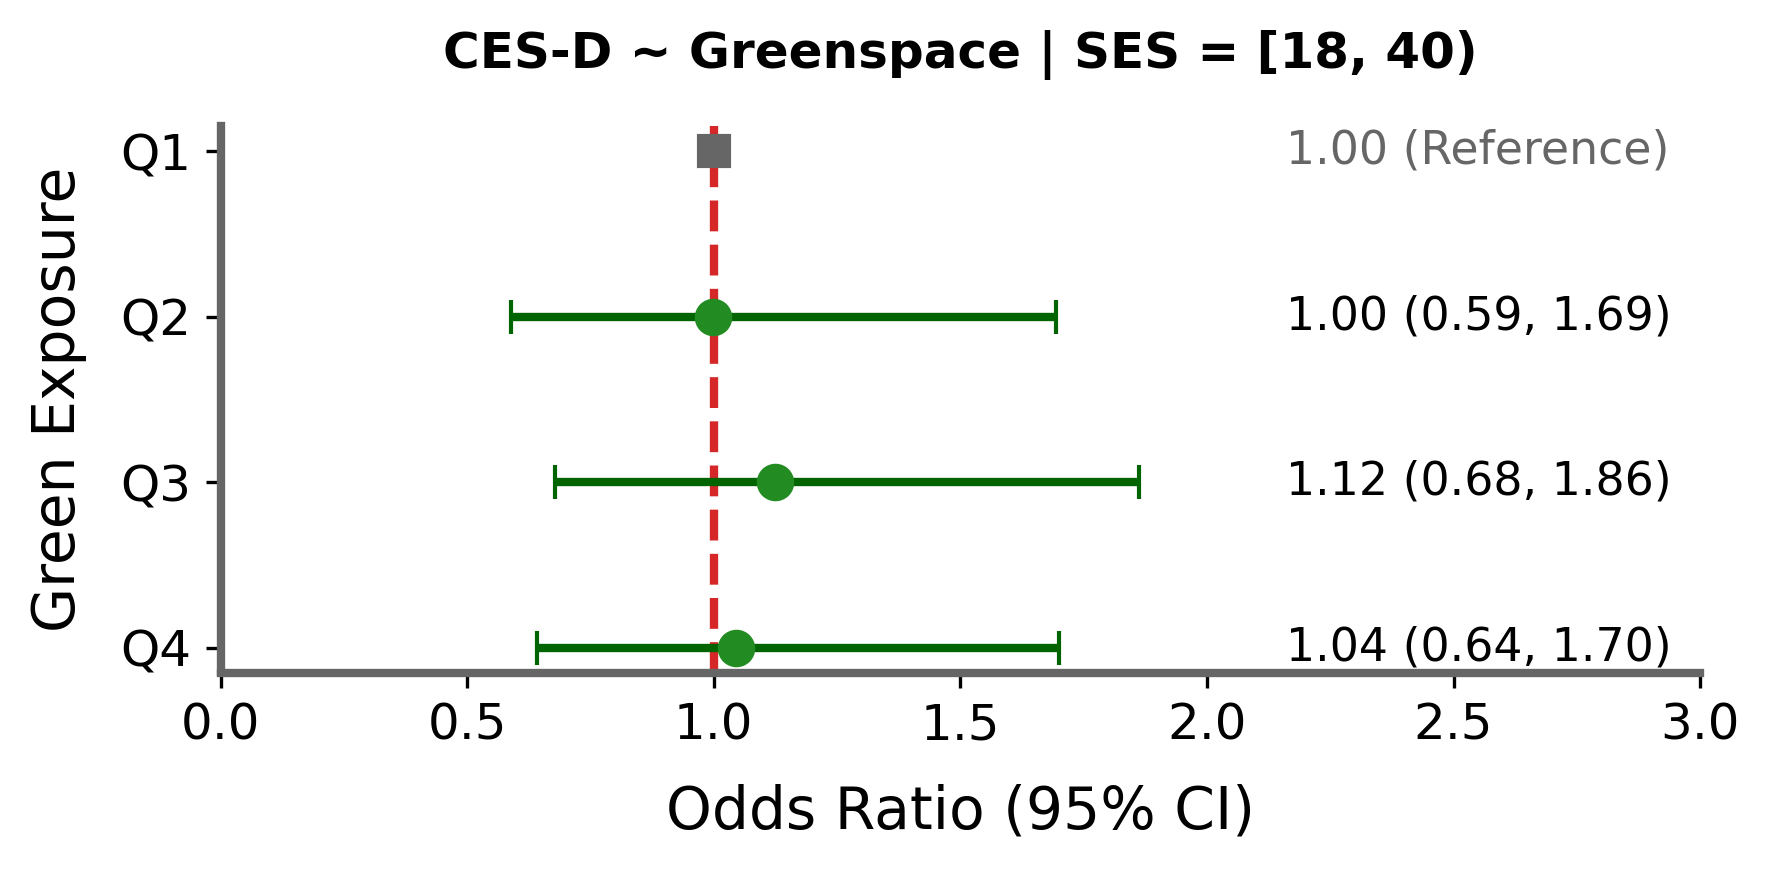

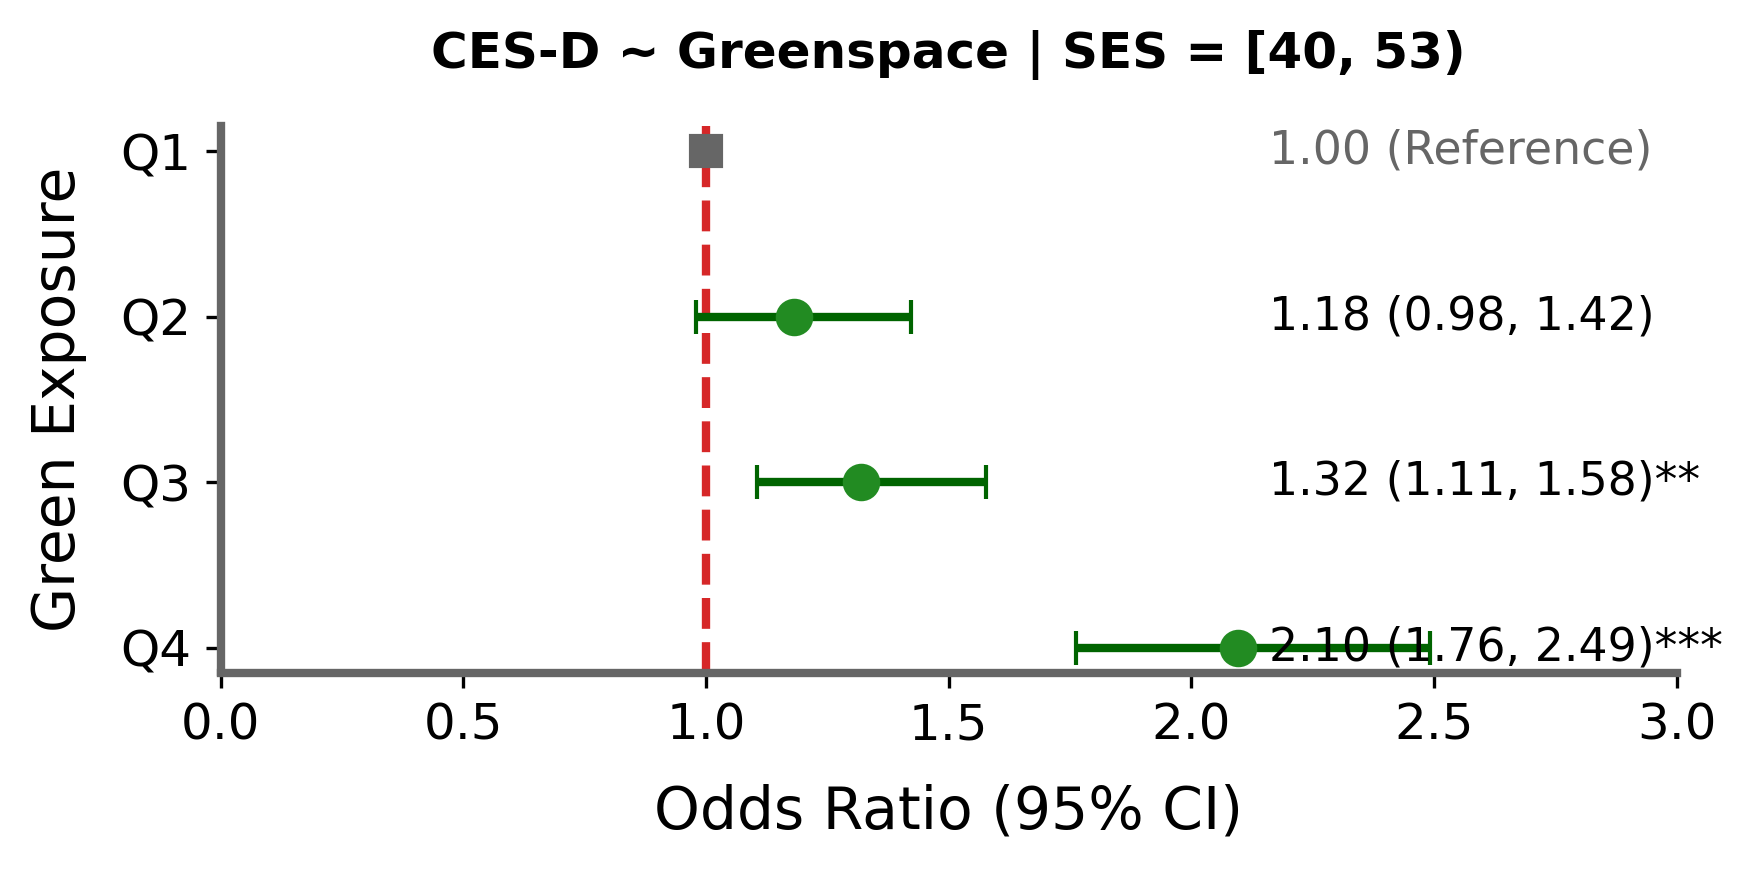

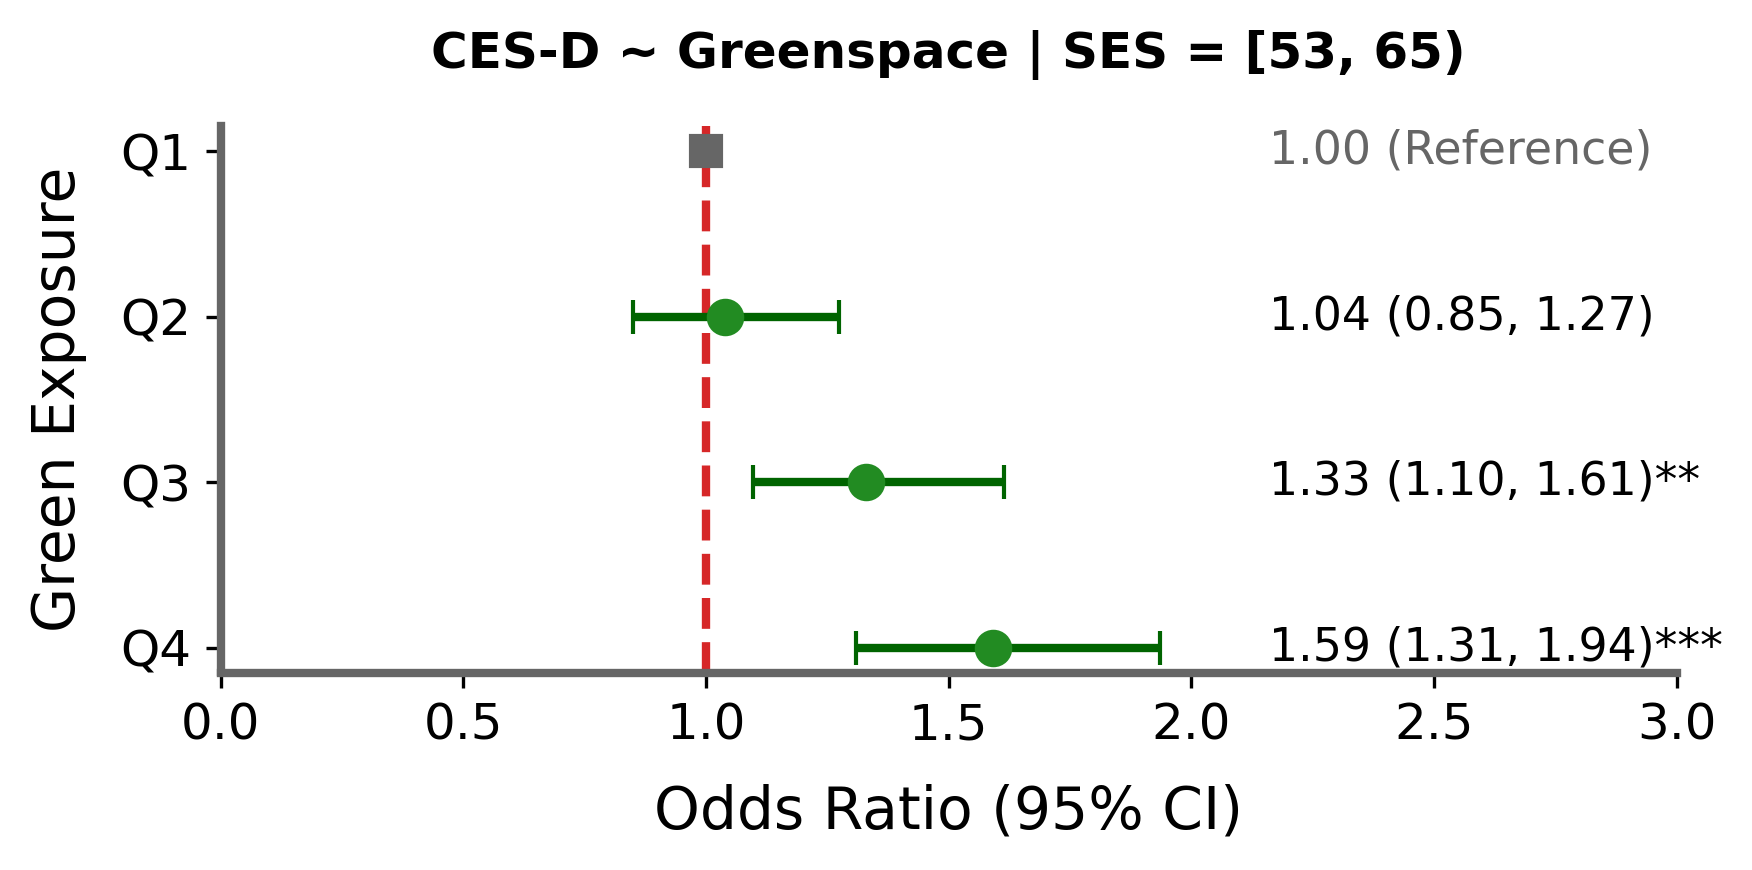

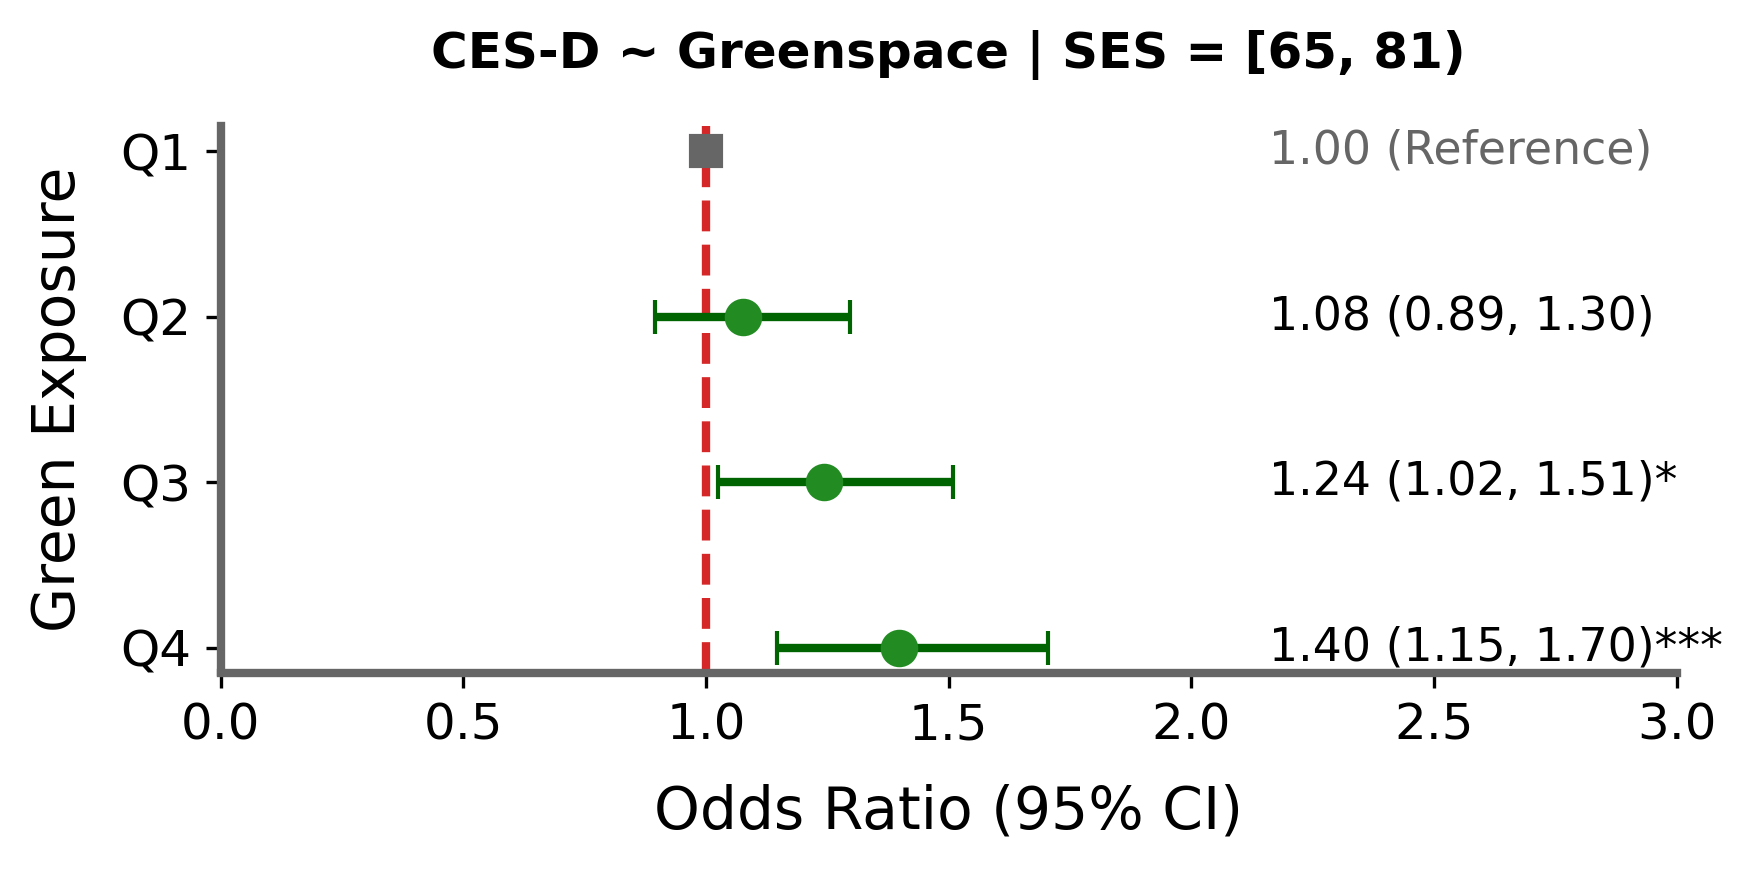

In [59]:
# Forest plot per stratum
for ses, res in strata_results.items():
    ordinal.plot_forest(
        res["or_table"],
        title = f"CES-D ~ Greenspace | SES = {ses}",
        predictor_type = "categorical"
    )

# Interaction Ordinal Model – Experiments

## SES-moderator: Mental Scores across NDVI

In [74]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_ordinal,
    predictors            = cols.ndvi,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "ordinal",
    predictor_type        = "continuous",
    scale_predictor       = 0.1,
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Ordinal × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [2/12] CES-D Ordinal × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [3/12] CES-D Ordinal × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [4/12] CES-D Ordinal × NDVI (1000m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9117 | 0/2 interaction terms p < 0.05
  [5/12] GAD-7 Ordinal × NDVI (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [6/12] GAD-7 Ordinal × NDVI (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9278 | 0/2 interaction terms p < 0.05
  [7/12] GAD-7 Ordinal × NDVI (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Save Interaction Model results to `ordinal_results` in `pkl` and `csv`

In [75]:
##out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results.csv


## SES-moderator: Mental Scores across Green Space Quartiles

In [90]:
data = data_complete.copy()

inter_df, inter_store = experiment.run_interaction_grid(
    data                  = data,
    outcomes              = cols.mental_ordinal,
    predictors            = cols.greenspace_quartiles,
    moderator             = "Socioeconomic Status (Tiers)",
    moderator_type        = "categorical",
#    moderator_reference   = 1.0,
    model_type            = "ordinal",
    predictor_type        = "categorical",
    reference_category    = "1.0",
    label_mapping         = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    outcome_direction_map = outcome_direction_map,
    covariates            = ["Sex", "Age"],
)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

  [1/12] CES-D Ordinal × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [2/12] CES-D Ordinal × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [3/12] CES-D Ordinal × Green Space Quartile (500m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 1/6 interaction terms p < 0.05
  [4/12] CES-D Ordinal × Green Space Quartile (1000m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9079 | 0/6 interaction terms p < 0.05
  [5/12] GAD-7 Ordinal × Green Space Quartile (100m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9238 | 0/6 interaction terms p < 0.05
  [6/12] GAD-7 Ordinal × Green Space Quartile (200m Buffer)  [× Socioeconomic Status (Tiers), ordinal]
  Interaction fitted | n = 9238 | 0/6 interaction terms 

,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.796,"2.217 (1.236, 3.976)",0.008,121.7,"Sex, Age",True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.356,"1.427 (1.023, 1.991)",0.036,42.7,"Sex, Age",True


## Save Interaction Model results to `ordinal_results` in `pkl` and `csv`

In [91]:
##out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
##experiment.save_results(inter_df, inter_store, path=out_path)

  Saved pickle : outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results.pkl
  Saved CSV    : outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results.csv


# Analysis – SES-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [92]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:51:55.556287


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. NDVI – adjusted: Sex, Age

In [93]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:52:38.217339


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [94]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T18:02:44.164463


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.816,"2.262 (1.265, 4.046)",0.006,126.2,unadjusted,True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.361,"1.434 (1.033, 1.992)",0.031,43.4,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, Age

In [95]:
out_path = f"outputs/ordinal/interaction_ses/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T18:03:51.313475


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
14,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.796,"2.217 (1.236, 3.976)",0.008,121.7,"Sex, Age",True
38,GAD-7 Ordinal,Green Space Quartile (500m Buffer),9238,Socioeconomic Status (Tiers),2.0,Q1,Q4,0.356,"1.427 (1.023, 1.991)",0.036,42.7,"Sex, Age",True


# Analysis – Age-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [96]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:49:45.423706


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
6,CES-D Ordinal,NDVI (500m Buffer),9142,Age_group,"[40, 53)",0.1,-0.488,"0.614 (0.395, 0.954)",0.030,38.6,unadjusted,True
7,CES-D Ordinal,NDVI (500m Buffer),9142,Age_group,"[53, 65)",0.1,-0.572,"0.564 (0.361, 0.882)",0.012,43.6,unadjusted,True
8,CES-D Ordinal,NDVI (500m Buffer),9142,Age_group,"[65, 81)",0.1,-0.462,"0.630 (0.398, 0.998)",0.049,37.0,unadjusted,True


## Mental Scores vs. NDVI – adjusted: Sex, SES

In [97]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:50:47.397181


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
6,CES-D Ordinal,NDVI (500m Buffer),9117,Age_group,"[40, 53)",0.1,-0.472,"0.624 (0.398, 0.977)",0.039,37.6,"Sex, Socioeconomic Status (Tiers)",True
7,CES-D Ordinal,NDVI (500m Buffer),9117,Age_group,"[53, 65)",0.1,-0.566,"0.568 (0.359, 0.899)",0.016,43.2,"Sex, Socioeconomic Status (Tiers)",True
10,CES-D Ordinal,NDVI (1000m Buffer),9117,Age_group,"[53, 65)",0.1,-0.525,"0.592 (0.352, 0.995)",0.048,40.8,"Sex, Socioeconomic Status (Tiers)",True


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [98]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T18:01:35.684987


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
11,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-1.391,"0.249 (0.099, 0.627)",0.003,75.1,unadjusted,True
14,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[53, 65)",Q1,Q4,-1.574,"0.207 (0.080, 0.537)",0.001,79.3,unadjusted,True
17,CES-D Ordinal,Green Space Quartile (200m Buffer),9104,Age_group,"[65, 81)",Q1,Q4,-1.211,"0.298 (0.111, 0.798)",0.016,70.2,unadjusted,True
20,CES-D Ordinal,Green Space Quartile (500m Buffer),9104,Age_group,"[40, 53)",Q1,Q4,-1.158,"0.314 (0.113, 0.872)",0.026,68.6,unadjusted,True
50,GAD-7 Ordinal,Green Space Quartile (200m Buffer),9264,Age_group,"[53, 65)",Q1,Q4,-0.711,"0.491 (0.253, 0.954)",0.036,50.9,unadjusted,True
80,SWLS Ordinal,Green Space Quartile (100m Buffer),9283,Age_group,"[65, 81)",Q1,Q4,-0.527,"0.590 (0.354, 0.983)",0.043,41.0,unadjusted,True
92,SWLS Ordinal,Green Space Quartile (500m Buffer),9283,Age_group,"[40, 53)",Q1,Q4,0.710,"2.035 (1.169, 3.541)",0.012,103.5,unadjusted,True


## Mental Scores vs. Land-use-based Quartiles – adjusted: Sex, SES

In [99]:
out_path = f"outputs/ordinal/interaction_age/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T18:00:03.209835


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant
1,CES-D Ordinal,Green Space Quartile (100m Buffer),9079,Age_group,"[40, 53)",Q1,Q3,-1.195,"0.303 (0.093, 0.989)",0.048,69.7,"Sex, Socioeconomic Status (Tiers)",True
4,CES-D Ordinal,Green Space Quartile (100m Buffer),9079,Age_group,"[53, 65)",Q1,Q3,-1.226,"0.294 (0.089, 0.972)",0.045,70.6,"Sex, Socioeconomic Status (Tiers)",True
11,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-1.403,"0.246 (0.091, 0.660)",0.005,75.4,"Sex, Socioeconomic Status (Tiers)",True
14,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[53, 65)",Q1,Q4,-1.568,"0.208 (0.075, 0.576)",0.002,79.2,"Sex, Socioeconomic Status (Tiers)",True
17,CES-D Ordinal,Green Space Quartile (200m Buffer),9079,Age_group,"[65, 81)",Q1,Q4,-1.136,"0.321 (0.112, 0.917)",0.034,67.9,"Sex, Socioeconomic Status (Tiers)",True
20,CES-D Ordinal,Green Space Quartile (500m Buffer),9079,Age_group,"[40, 53)",Q1,Q4,-1.234,"0.291 (0.098, 0.865)",0.026,70.9,"Sex, Socioeconomic Status (Tiers)",True
50,GAD-7 Ordinal,Green Space Quartile (200m Buffer),9238,Age_group,"[53, 65)",Q1,Q4,-0.709,"0.492 (0.252, 0.961)",0.038,50.8,"Sex, Socioeconomic Status (Tiers)",True
80,SWLS Ordinal,Green Space Quartile (100m Buffer),9257,Age_group,"[65, 81)",Q1,Q4,-0.616,"0.540 (0.324, 0.899)",0.018,46.0,"Sex, Socioeconomic Status (Tiers)",True
92,SWLS Ordinal,Green Space Quartile (500m Buffer),9257,Age_group,"[40, 53)",Q1,Q4,0.635,"1.888 (1.083, 3.291)",0.025,88.8,"Sex, Socioeconomic Status (Tiers)",True


# Analysis – Sex-Moderator Ordinal Model

## Mental Scores vs. NDVI – unadjusted

In [100]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/ndvi/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:45:53.185958


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. NDVI – adjusted: Age, SES

In [101]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/ndvi/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "scale_predictor", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:46:26.987339


,outcome,predictor,n,moderator,moderator_level,scale_predictor,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – unadjusted

In [102]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/quartiles/unadjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:55:24.899628


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


## Mental Scores vs. Land-use-based Quartiles – adjusted: Age, SES

In [103]:
out_path = f"outputs/ordinal/interaction_sex/mental_ordinal/quartiles/adjusted/ordinal_results"
inter_df, inter_store = experiment.load_results(out_path)

columns = ["outcome", "predictor", "n", "moderator", "moderator_level", "reference_level", "level", 
           "beta", "OR_95CI", "p_value_fmt", "pct_change_odds", "covariates", "significant"]

inter_df.query(f"significant == True")[columns]

#outcome = cols.mental_numeric
#predictor = cols.ndvi[2]
#inter_df.query(f"outcome == @outcome and predictor == @predictor")[columns]

  Loaded results saved at: 2026-09-14T17:54:29.736373


,outcome,predictor,n,moderator,moderator_level,reference_level,level,beta,OR_95CI,p_value_fmt,pct_change_odds,covariates,significant


# Interaction Ordinal Model – Single Mental Health Variable

In [104]:
data = data_complete.copy()

result, meta, interaction_table = ordinal.fit_interaction(
    data                = data,
    outcome             = "SWLS Ordinal", #"CES-D Ordinal",
    predictor           = "NDVI (500m Buffer)", #"Green Space Quartile (500m Buffer)",
    moderator           = "Socioeconomic Status (Tiers)",
    moderator_type      = "categorical",
#    moderator_reference = 1.0, # low SES as reference
    predictor_type      = "continuous",
    scale_predictor     = 0.1,
#    reference_category  = "1.0",
#    label_mapping       = {"1.0": "Q1", "2.0": "Q2", "3.0": "Q3", "4.0": "Q4"},
    #covariates          = ["Age", "Sex"],
)

display(interaction_table)

  Interaction fitted | n = 9297 | 0/2 interaction terms p < 0.05


,outcome,predictor,predictor_type,moderator,scale_predictor,reference_level,level,moderator_level,beta,OR,CI_lower,CI_upper,OR_95CI,p_value,p_value_fmt,pct_change_odds,covariates,cov_type,significant
0,SWLS Ordinal,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),2.0,0.070,1.073,0.939,1.226,"1.073 (0.939, 1.226)",0.301331,0.301,7.3,unadjusted,HC3,False
1,SWLS Ordinal,NDVI (500m Buffer),continuous,Socioeconomic Status (Tiers),0.1,None,NDVI (500m Buffer),3.0,-0.056,0.946,0.814,1.099,"0.946 (0.814, 1.099)",0.467766,0.468,5.4,unadjusted,HC3,False
